# 02 - Overfitting and Spatial K-Fold Cross-Validation in CNNs (GPU Accelerated)

This notebook demonstrates **CNN overfitting** and implements **Spatial K-Fold Cross-Validation** using real images from `torchvision.datasets.FashionMNIST` with **GPU acceleration**.

---

## Topics Covered:

1. **GPU Device Configuration**: `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`.
2. **CNN Overfitting**: Training a high-capacity CNN on a small subset of real FashionMNIST images on GPU.
3. **Spatial K-Fold Cross-Validation**: GPU tensor transfers per fold.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as torch_optim
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import FashionMNIST
from sklearn.model_selection import KFold

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


Using Device: cuda


## 1. Load Small Real FashionMNIST Subset


In [9]:
transform = T.Compose([T.ToTensor(), T.Normalize((0.2860,), (0.3530,))])

full_fmnist = FashionMNIST(root='./data', train=True, download=True, transform=transform)

small_indices = list(range(150))
small_dataset = Subset(full_fmnist, small_indices)

train_sub = Subset(small_dataset, list(range(100)))
val_sub = Subset(small_dataset, list(range(100, 150)))

loader_tr = DataLoader(train_sub, batch_size=16, shuffle=True)
loader_val = DataLoader(val_sub, batch_size=16, shuffle=False)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.5MB/s]


## 2. Overfitting Training Loop on GPU


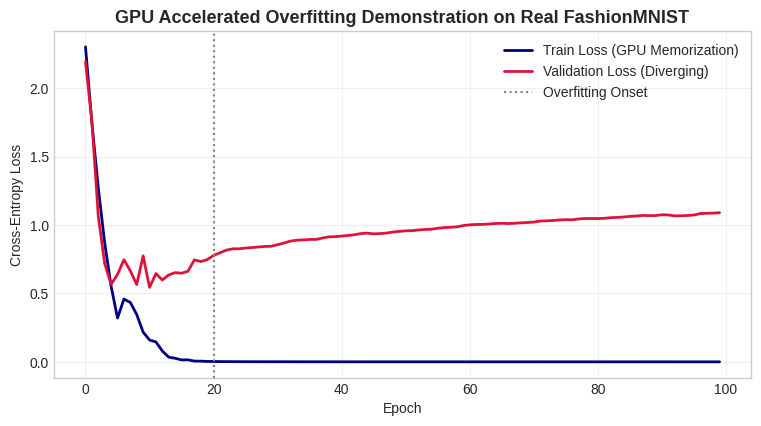

In [10]:
class ComplexFashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model_overfit = ComplexFashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch_optim.Adam(model_overfit.parameters(), lr=0.001)

train_losses, val_losses = [], []
for epoch in range(1, 101):
    model_overfit.train()
    tr_loss = 0.0
    for bx, by in loader_tr:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model_overfit(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * len(by)
    tr_loss /= len(train_sub)
    
    model_overfit.eval()
    v_loss = 0.0
    with torch.no_grad():
        for bx, by in loader_val:
            bx, by = bx.to(device), by.to(device)
            v_loss += criterion(model_overfit(bx), by).item() * len(by)
    v_loss /= len(val_sub)
    
    train_losses.append(tr_loss)
    val_losses.append(v_loss)

plt.figure(figsize=(9, 4.5))
plt.plot(train_losses, label='Train Loss (GPU Memorization)', color='navy', linewidth=2)
plt.plot(val_losses, label='Validation Loss (Diverging)', color='crimson', linewidth=2)
plt.axvline(x=20, color='gray', linestyle=':', label='Overfitting Onset')
plt.title('GPU Accelerated Overfitting Demonstration on Real FashionMNIST', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Spatial K-Fold Cross-Validation on GPU


In [11]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(small_dataset), start=1):
    f_train_sub = Subset(small_dataset, train_idx)
    f_val_sub = Subset(small_dataset, val_idx)
    
    l_tr = DataLoader(f_train_sub, batch_size=16, shuffle=True)
    l_val = DataLoader(f_val_sub, batch_size=16, shuffle=False)
    
    fold_cnn = nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
        nn.Linear(64, 10)
    ).to(device) # Move fold model to GPU
    
    f_opt = torch_optim.Adam(fold_cnn.parameters(), lr=0.002)
    f_crit = nn.CrossEntropyLoss()
    
    for epoch in range(35):
        fold_cnn.train()
        for bx, by in l_tr:
            bx, by = bx.to(device), by.to(device)
            f_opt.zero_grad()
            loss = f_crit(fold_cnn(bx), by)
            loss.backward()
            f_opt.step()
            
    fold_cnn.eval()
    v_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in l_val:
            bx, by = bx.to(device), by.to(device)
            out = fold_cnn(bx)
            v_loss += f_crit(out, by).item() * len(by)
            correct += (torch.argmax(out, dim=1) == by).sum().item()
            total += len(by)
            
    f_val_loss = v_loss / total
    f_val_acc = correct / total
    fold_results.append({'fold': fold, 'val_loss': f_val_loss, 'val_acc': f_val_acc})
    print(f"Fold {fold}/{K} | Val Loss: {f_val_loss:.4f} | Val Accuracy: {f_val_acc*100:.2f}%")


Fold 1/5 | Val Loss: 0.8762 | Val Accuracy: 73.33%
Fold 2/5 | Val Loss: 0.9943 | Val Accuracy: 90.00%
Fold 3/5 | Val Loss: 1.7659 | Val Accuracy: 63.33%
Fold 4/5 | Val Loss: 0.7277 | Val Accuracy: 80.00%
Fold 5/5 | Val Loss: 0.3756 | Val Accuracy: 93.33%
